# 第五讲：VAE 与 Diffusion

这一讲的主线不是把模型名单罗列一遍，而是回答一个连续的问题：

> **从“压缩再重建”走到“逐步去噪生成”，视觉生成模型到底是怎么一步步演化出来的？**

这份 notebook 按下面的逻辑展开：

1. 先从 autoencoder 的目标出发，解释为什么 VAE 要把隐变量变成“分布”。
2. 用一个从零实现的 VAE，在 MNIST 上跑出重建、潜空间分布和插值。
3. 再解释为什么只有 VAE 还不够，于是需要 diffusion。
4. 用一个 CPU 友好的 toy diffuser 把“加噪 / 去噪 / 采样”真正跑起来。
5. 最后把这一条线收束到 Stable Diffusion 和 ControlNet。

## 本节课学习目标

1. 理解 autoencoder、VAE、DDPM、latent diffusion、ControlNet 之间的关系。
2. 讲清 VAE 的三个关键对象：`mu`、`logvar`、`reparameterization`。
3. 理解 diffusion 的训练目标为什么是“预测噪声”。
4. 看懂图像 diffusion 里 `scheduler`、`UNet`、`condition` 各自承担什么角色。
5. 能跑通两个实操：`VAE on MNIST` 和 `toy diffusion on two moons`。

## 这一讲怎么编排

<img src="images/lesson5_generative/generative_map.png" width="980">

这一讲建议按三个层次展开：

- **第一层：先讲 VAE。** 它和 autoencoder 的联系最直接，适合先建立“隐变量生成”的直觉。
- **第二层：再讲 diffusion。** 它解决的是更高质量、更稳定的生成问题。
- **第三层：最后讲 Stable Diffusion / ControlNet。** 这时再回头看系统组件，逻辑会顺很多。

## 这份 notebook 主要参考了哪些原始材料

来自书里的可用内容主要有：

- `VAE.ipynb`
- `Diffusion_Pytorch.ipynb`
- `Conditional_Diffuser_training.ipynb`
- `Unet_Components_from_scratch.ipynb`
- `Stable_Diffusion_pipeline.ipynb`
- `ControlNet-Inference.ipynb`

这些原始 notebook 有两个问题：

- 它们更偏“单点 demo”，而不是一节课的连续叙事。
- Stable Diffusion / ControlNet 部分默认假设 GPU 较强。

所以下面的版本会重新组织成：**概念解释 + CPU 默认可跑的主线实操 + 大模型部分的可选扩展**。

In [1]:
# ------------------------------
# 这段代码做什么：
# 1. 导入本讲要用到的依赖
# 2. 固定随机种子，保证结果更稳定
# 3. 设置运行设备和几个可选开关
# ------------------------------
from pathlib import Path
import math
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from diffusers import DDPMScheduler, UNet2DModel
from sklearn.datasets import make_moons
from PIL import Image, ImageDraw
import cv2

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

device = "cuda" if torch.cuda.is_available() else "cpu"
RUN_HEAVY_MODELS = False  # 如需尝试 Stable Diffusion / ControlNet，可手动改成 True
DATA_ROOT = Path.home() / "data"

print("device =", device)
print("RUN_HEAVY_MODELS =", RUN_HEAVY_MODELS)

/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device = cpu
RUN_HEAVY_MODELS = False


/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


# Part 1. 从 Autoencoder 走到 VAE

一开始先不要急着写公式，先看最基本的 autoencoder 在做什么：

- 编码器把输入 `x` 压到一个低维表示 `z`
- 解码器再从 `z` 重建出 `x_hat`

这样做可以学到一个压缩表示，但它有一个生成上的问题：

> **普通 autoencoder 学到的是“点”，不是“规则良好的分布”。**

这会带来两个后果：

- 不同样本之间的潜空间可能有“空洞”，随机采样不稳定。
- 插值不一定平滑，生成时容易跑到训练分布之外。

所以 VAE 做了一个关键修改：

- 编码器不再直接输出一个确定的点
- 而是输出一个高斯分布 `q(z|x)` 的参数：`mu` 和 `logvar`

## 先把 VAE 里的符号讲清楚

VAE 的生成视角是：

1. 先决定一组隐藏因素 `z`
2. 再根据 `z` 生成图像 `x`

公式写成：

$$
z \sim p(z)=\mathcal N(0, I)
$$

$$
x \sim p_\theta(x|z)
$$

这里可以把 `z` 理解成“图像背后的隐藏原因”，例如手写数字的：

- 粗细
- 倾斜方向
- 书写风格
- 数字类别相关的抽象因素

训练时真正拿到的是图像 `x`，但没有人把这张图背后的 `z` 直接告诉我们。  
所以需要做一件“反推”的事：

> 已经看到了结果 `x`，现在去猜这张图最可能对应哪些 `z`。

这时出现的就是后验分布：

$$
p(z|x)
$$

但真实后验通常很难直接算，所以 VAE 用一个编码器去近似它：

$$
q_\phi(z|x)=\mathcal N(\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x)))
$$

这就是为什么 VAE 要引入编码器。  
编码器的作用不是随便“压缩一下图片”，而是：

> **根据图像 `x`，输出这张图对应的潜变量分布 `q(z|x)`。**

这里也能顺手解释两个常见疑问：

- 为什么是后验分布？  
  因为现在是“先看到了 `x`，再去推 `z`”，这是典型的后验推断。
- 为什么 KL 里拿 `q(z|x)` 和 `p(z)` 比，而不是和 `p(x)` 比？  
  因为 `q(z|x)` 是“关于 `z` 的分布”，KL 必须比较同一个变量上的两个分布，所以要和先验 `p(z)` 比，而不是和图像分布 `p(x)` 比。

## VAE 的目标函数到底是什么

VAE 想最大化的是数据的对数似然 `\log p_\theta(x)`，但它不好直接算。  
所以实际优化的是一个下界 `ELBO`：

$$
\log p_\theta(x)\ge
\mathbb E_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
D_{KL}(q_\phi(z|x)\|p(z))
$$

课堂上更建议先把它读成下面这句，而不是把中文硬塞进公式里：

$$
\mathrm{ELBO}(x)=
\mathbb E_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
D_{KL}(q_\phi(z|x)\|p(z))
$$

这里的两项分别表示：

- 第一项：**重建好不好**
- 第二项：**潜空间规不规整**

通常把它改写成最小化损失：

$$
\mathcal L_{\text{VAE}}
=
-\mathbb E_{q_\phi(z|x)}[\log p_\theta(x|z)]
+
D_{KL}(q_\phi(z|x)\|p(z))
$$

这两项分别对应两件事：

1. **重建项**

$$
-\mathbb E_{q_\phi(z|x)}[\log p_\theta(x|z)]
$$

它的作用是：  
从 `z` 解码出来的 `x_hat` 要尽量像原图 `x`。

2. **KL 项**

$$
D_{KL}(q_\phi(z|x)\|p(z))
$$

它的作用是：  
让每张图对应的潜变量分布 `q(z|x)` 不要偏离统一先验 `p(z)=N(0,I)` 太远。

如果 `q(z|x)` 是对角高斯，那么 KL 项可以写成闭式公式：

$$
D_{KL}(q_\phi(z|x)\|p(z))
=
-\frac12\sum_i \left(1+\log \sigma_i^2-\mu_i^2-\sigma_i^2\right)
$$

这就是代码里那一项：

```python
kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
```

## 为什么一定要引入 KL 项

如果没有 KL 项，只保留重建项，会发生什么？

- 编码器完全可以把每张训练图扔到潜空间里任意一个角落
- decoder 只要记住“这个角落对应哪张图”就能把训练样本重建得很好

所以会出现一个现象：

> **没有 KL 时，重建训练样本通常没问题；但随机生成新样本往往很差。**

原因是：

- 重建训练样本时，用的是 `z = encoder(x)`，也就是训练时真的出现过的那些 latent code
- 随机生成新样本时，用的是 `z \sim N(0,I)`，这是在整个潜空间里随机采样

如果潜空间没有被 KL 项规整过，训练样本对应的 `z` 可能只是一些分散的小岛：

- decoder 认识这些“小岛”
- 但随机采样得到的 `z` 往往落在小岛之外的空白区域

于是就会出现：

- 重建时看起来没问题
- 生成时输出很怪
- 插值时中间路径不平滑

所以可以把 VAE 记成一句话：

- **重建项管 `x`：保证原图能还原回来**
- **KL 项管 `z`：保证潜空间规整、连续、可采样**

<img src="images/lesson5_generative/vae_pipeline.png" width="980">

### 这一张图里最值得停下来的地方

1. **重建项**：希望 `x_hat` 能尽量接近 `x`
2. **KL 项**：希望每个样本对应的 `q(z|x)` 不要太偏离标准正态 `N(0, I)`
3. **重参数化**：`z = mu + sigma * eps`，这样反向传播仍然能穿过采样过程

可以先想一个问题：

> 如果直接写成 `z ~ N(mu, sigma^2)` 然后硬采样，梯度为什么不容易直接传回 `mu` 和 `sigma`？

### 为什么不能直接“硬采样”

这件事可以先不用公式，先从直觉讲。

如果直接写：

$$
z \sim \mathcal N(\mu, \sigma^2)
$$

那就等于说：

- 给定 `mu`
- 给定 `sigma`
- 然后从这个分布里**随机抽**一个 `z`

问题就在这个“抽”字上。  
反向传播最喜欢的是下面这种关系：

$$
z = f(\mu, \sigma)
$$

也就是：

- `z` 明确由 `mu` 和 `sigma` 算出来
- 这样才能继续算梯度

但“直接从分布里抽一下”更像一个黑盒动作。  
比如现在：

- `mu = 2.0`
- `sigma = 0.5`
- 最后抽到了 `z = 1.7`

这时如果 loss 变差了，就会卡住一个问题：

> 这个 `1.7` 到底是因为 `mu` 该调，还是 `sigma` 该调，还是只是这次随机抽样运气不好？

这就是为什么直接硬采样时，梯度不容易直接穿过去。

可以把它想成“抽签”或者“做菜”：

- 抽签版：只知道最后抽到了一个结果，但中间是随机动作，梯度没法顺着抽签过程继续往回走。
- 做菜版：如果最后这盘菜太咸了，你不知道到底是平均放盐量不对，还是这次手抖太厉害，还是纯粹运气不好。

所以 VAE 不直接写硬采样，而是改写成：

$$
\epsilon \sim \mathcal N(0,1)
$$

$$
z = \mu + \sigma \epsilon
$$

这样随机性就被单独放进 `eps` 里，而 `z` 变成了一个明确的可导函数。

例如：

- `mu = 2.0`
- `sigma = 0.5`
- 假设这次采到 `eps = -0.6`

那么：

$$
z = 2.0 + 0.5 \times (-0.6) = 1.7
$$

这时 `1.7` 就不是一个黑盒抽样结果，而是一个明确表达式的输出。  
自动求导就能看清：

- `mu` 变大，`z` 会怎么变
- `sigma` 变大，`z` 会怎么变

所以一句话总结就是：

> **不是不能随机，而是要把随机性和可导参数拆开。**

**论文截图：Auto-Encoding Variational Bayes, Kingma & Welling, 2013**

<img src="images/lesson5_generative/vae_paper_fig.png" width="720">

这张图来自原论文的 Figure 1。它最大的价值不是“结构复杂”，而是第一次把  
`p_theta(x|z)` 和 `q_phi(z|x)` 这两个方向放到同一个图里：  
一个负责生成，一个负责近似后验。

论文链接：<https://arxiv.org/abs/1312.6114>

## 为什么先用 MNIST 讲 VAE

这一讲的 VAE 实操故意选 `MNIST`，原因是：

- 图像小，CPU 也能很快跑完
- 2 维潜变量可视化效果直观
- 数字类别让潜空间结构更容易解释

这里的重点不是把精度刷高，而是把下面三件事真正看见：

- 重建图像会变成什么样
- 潜空间分布是否连续
- 插值时生成结果是否平滑变化

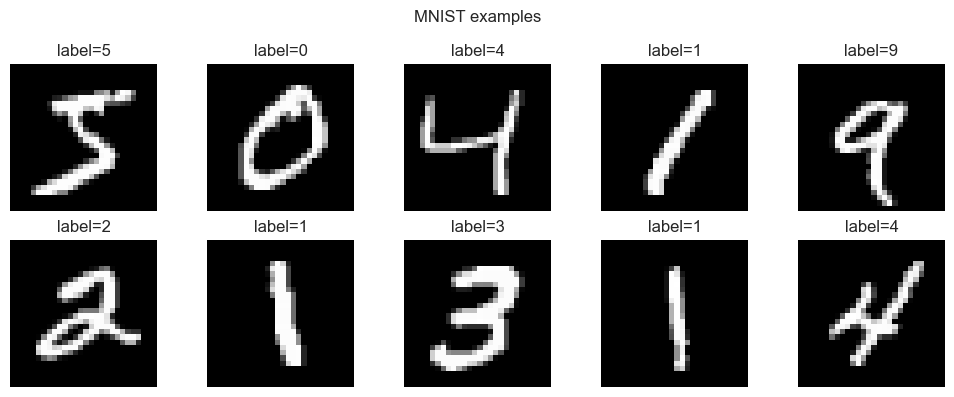

In [2]:
# ------------------------------
# 这段代码做什么：
# 1. 读取一个较小的 MNIST 子集
# 2. 先看几张样本图像，为后面的重建和生成做参照
# ------------------------------
transform = transforms.ToTensor()
train_raw = datasets.MNIST(DATA_ROOT / "MNIST", train=True, download=True, transform=transform)
val_raw = datasets.MNIST(DATA_ROOT / "MNIST", train=False, download=True, transform=transform)

# 为了课堂演示速度，这里只取一个较小子集。
train_ds = Subset(train_raw, list(range(4096)))
val_ds = Subset(val_raw, list(range(1024)))

# train_dl 用于参数更新，val_dl 用于观察泛化和可视化。
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    image, label = train_raw[idx]
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"label={label}")
    ax.axis("off")
plt.suptitle("MNIST examples")
plt.tight_layout()
plt.show()

### 提问环节

看到这里，可以先停一下：

- 如果只做普通重建，编码器输出一个确定的向量就够了，为什么还需要 `mu` 和 `logvar`？
- 如果想从模型里“采样新图像”，潜空间最好具有什么性质？

VAE 的核心目标，就是把“好重建”和“好采样”同时兼顾起来。

In [3]:
# ------------------------------
# 这段代码做什么：
# 1. 从零定义一个最小 VAE
# 2. 把 encoder / reparameterization / decoder 拆开写清楚
# 3. 同时返回总 loss、重建项和 KL 项，方便课堂分析
# ------------------------------
class SmallVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        # encoder: 把 784 维像素压到一个隐藏表示
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        # 两个分支分别输出高斯分布的均值和对数方差
        self.mu_head = nn.Linear(128, latent_dim)
        self.logvar_head = nn.Linear(128, latent_dim)
        # decoder: 从潜变量 z 还原回图像 logits
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),   # 输出 logits，后面再交给 BCEWithLogits
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # 先把 log-variance 变回标准差
        std = torch.exp(0.5 * logvar)
        # eps 提供随机性，但梯度仍然能通过 mu / std 传回去
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        # 1) 编码得到分布参数
        mu, logvar = self.encode(x)
        # 2) 从这个分布里采样潜变量
        z = self.reparameterize(mu, logvar)
        # 3) 再把潜变量解码成重建图像
        logits = self.decode(z)
        return logits, mu, logvar, z


def vae_loss(logits, x, mu, logvar, beta=1.0):
    # 重建项：像素级重建误差
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="sum")
    # KL 项：把 q(z|x) 拉向 N(0, I)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + beta * kl
    return total, recon, kl


def run_epoch(loader, model, optimizer=None, beta=1.0):
    is_train = optimizer is not None
    model.train(is_train)
    stats = {"loss": 0.0, "recon": 0.0, "kl": 0.0, "n": 0}

    for x, _ in loader:
        # VAE 这里用的是全连接网络，所以先把图像展平
        x = x.to(device).view(len(x), -1)
        logits, mu, logvar, _ = model(x)
        loss, recon, kl = vae_loss(logits, x, mu, logvar, beta=beta)

        if is_train:
            # 只有训练阶段才做梯度更新
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 记录总损失、重建损失和 KL 损失，后面单独画曲线
        stats["loss"] += float(loss.item())
        stats["recon"] += float(recon.item())
        stats["kl"] += float(kl.item())
        stats["n"] += len(x)

    return {k: v / stats["n"] for k, v in stats.items() if k != "n"}


vae = SmallVAE(latent_dim=2).to(device)
vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
print(vae)

SmallVAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=128, out_features=2, bias=True)
  (logvar_head): Linear(in_features=128, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


### 这里要特别讲清楚三件事

1. `mu` 决定潜空间中心在哪里
2. `logvar` 决定这个分布有多“散”
3. `beta` 决定重建和分布正则之间的平衡

课堂里很容易把 VAE 讲成“就是 AE 多了个 KL”。不够。更准确的说法是：

> **VAE 不是只学一个隐变量点，而是在学一个可采样、可插值、可泛化的潜空间。**

In [4]:
# ------------------------------
# 这段代码做什么：
# 1. 训练一个小型 VAE
# 2. 分别记录 train / val 的 total loss、recon loss、KL loss
# ------------------------------
history = {
    "train_loss": [],
    "val_loss": [],
    "train_recon": [],
    "val_recon": [],
    "train_kl": [],
    "val_kl": [],
}

beta = 1.0
for epoch in range(3):
    # 先跑一轮训练，再在验证集上做一次前向检查
    train_stats = run_epoch(train_dl, vae, optimizer=vae_opt, beta=beta)
    val_stats = run_epoch(val_dl, vae, optimizer=None, beta=beta)

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_recon"].append(train_stats["recon"])
    history["val_recon"].append(val_stats["recon"])
    history["train_kl"].append(train_stats["kl"])
    history["val_kl"].append(val_stats["kl"])

    print(
        f"Epoch {epoch + 1}: "
        f"train_loss={train_stats['loss']:.2f}, "
        f"val_loss={val_stats['loss']:.2f}, "
        f"val_recon={val_stats['recon']:.2f}, "
        f"val_kl={val_stats['kl']:.2f}"
    )

Epoch 1: train_loss=318.72, val_loss=208.24, val_recon=205.60, val_kl=2.64


Epoch 2: train_loss=206.60, val_loss=199.49, val_recon=197.66, val_kl=1.84


Epoch 3: train_loss=198.39, val_loss=190.81, val_recon=188.79, val_kl=2.02


### 这三张曲线分别该怎么看

1. **Total loss** 看整体有没有变好。  
   这是 VAE 当前真正优化的总目标，可以理解为“重建项 + KL 项”的合成结果。

2. **Reconstruction loss** 看图像是不是越来越能重建好。  
   这条线通常是 **越低越好**。如果它持续下降，说明 decoder 越来越会把输入图像“复原回来”。  
   这一项对应的就是 VAE 里的 **重建项**。

3. **KL loss** 看潜空间是不是被拉向标准正态 `N(0, I)`。  
   这一项不是简单地“越低越绝对好”，它更多表示潜空间被约束得有多强。  
   可以把它理解成：这张图在管“潜空间规不规整”。

所以看 VAE 训练曲线时，不能只盯着总 loss。更重要的是同时看两件事：

- 图像重建能力有没有提升
- 潜空间有没有保持规整、可采样

**VAE 的难点就在这里：这两件事必须一起优化，而不是只顾一头。**

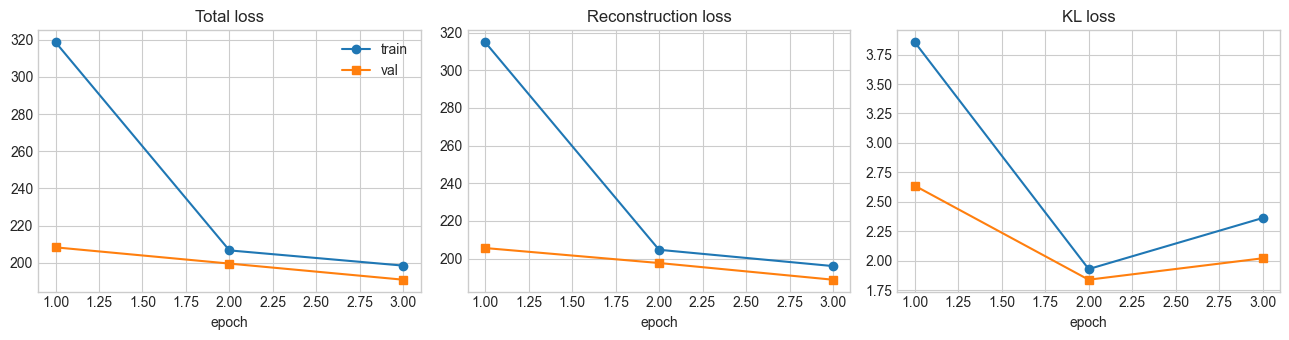

In [5]:
# ------------------------------
# 这段代码做什么：
# 1. 把 total / recon / KL 三条曲线画出来
# 2. 观察 VAE 是在优化“重建”和“潜空间正则”的折中
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
epochs = np.arange(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="s", label="val")
axes[0].set_title("Total loss")
axes[0].legend()

axes[1].plot(epochs, history["train_recon"], marker="o", label="train")
axes[1].plot(epochs, history["val_recon"], marker="s", label="val")
axes[1].set_title("Reconstruction loss")

axes[2].plot(epochs, history["train_kl"], marker="o", label="train")
axes[2].plot(epochs, history["val_kl"], marker="s", label="val")
axes[2].set_title("KL loss")

for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

### 这组原图 / 重建图在说明什么

这组图主要说明两件事：

1. **VAE 有没有学会把输入图像再画回来**  
   上排是原图 `orig`，下排是重建图 `recon`。如果下排仍然能看出鞋子、衣服、包等大致轮廓，说明模型已经学到了一些有效的潜变量表示。

2. **为什么 VAE 的重建常常会有一点模糊**  
   VAE 不是只顾着把图像抄回来，它还要满足 KL 约束，让潜空间保持规整、可采样。  
   所以它通常会保留主要结构，但细节会更软一些、边缘会更模糊一些。

读这组图时，可以重点观察：

- 原图和重建图的大轮廓是否一致
- 类别特征有没有被保留下来
- 模糊是不是主要出现在细节位置，而不是整体结构完全错掉

这段图最重要的结论是：

- 如果重建图还能看出类别，说明模型学到了整体语义和结构
- 如果重建图比原图模糊，说明 VAE 在“重建能力”和“潜空间规整”之间做了折中

还要特别区分一点：

> 这里展示的是 **重建**，不是 **随机生成**。  
> 也就是在看 `x -> z -> x_hat` 做得怎么样，而不是从 `z ~ N(0, I)` 随机采样后能生成什么图。

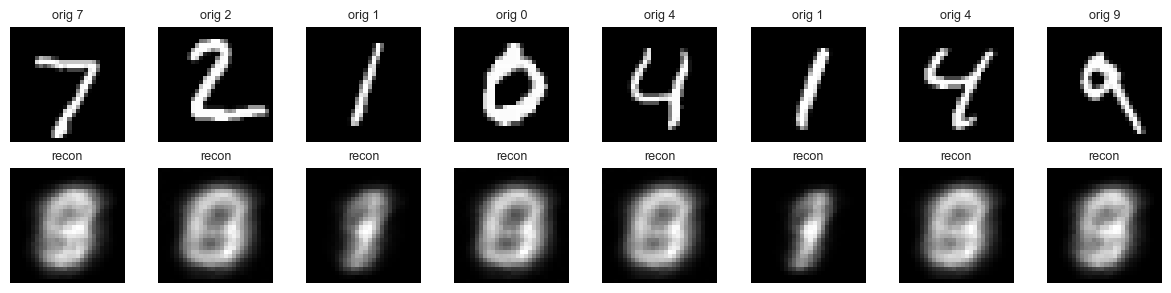

In [6]:
# ------------------------------
# 这段代码做什么：
# 1. 对比原图和 VAE 重建图
# 2. 观察 VAE 的重建能力与模糊现象
# ------------------------------
vae.eval()
x_vis, y_vis = next(iter(val_dl))
x_vis = x_vis[:8].to(device)

with torch.no_grad():
    # 这里仍然会走完整的 encode -> sample -> decode 过程
    logits, mu, logvar, z = vae(x_vis.view(len(x_vis), -1))
    # decoder 输出的是 logits，所以先过 sigmoid 才是像素概率
    recon = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x_vis[i].cpu().squeeze(0), cmap="gray")
    axes[0, i].set_title(f"orig {int(y_vis[i])}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].squeeze(0), cmap="gray")
    axes[1, i].set_title("recon", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### 这张五颜六色的潜空间散点图在说明什么

这张图的核心作用是：**把每张图像在潜空间里的位置画出来，看 VAE 学到的潜空间有没有结构。**

先看坐标和颜色分别代表什么：

- 横轴 `z1`、纵轴 `z2`：是潜变量的两个维度
- 每个点：是一张验证集图片
- 点的颜色：是真实类别标签，所以会看到很多不同颜色
- 这里画的是潜空间中心 `mu`，不是随机采样出来的 `z`，因为 `mu` 更稳定，更适合看整体分布

这张图主要回答三件事：

1. **同类样本会不会聚在一起**  
   如果相同颜色的点大致聚成团，说明编码器把相似图像映射到了相近的位置。  
   这表示潜空间学到了一些语义结构。

2. **不同类别是不是有一定分离**  
   如果不同颜色大致分布在不同区域，说明这个 2D latent space 有一定可解释性。  
   如果各种颜色完全搅在一起，说明潜空间区分度不强。

3. **潜空间是不是连续、规整**  
   VAE 不只是想把样本扔到几个孤岛上，还希望潜空间是平滑的、可采样的。  
   所以这里也在看：这些点是不是形成比较连续的区域，而不是特别碎、特别乱。

读这张图时，可以用下面的判断标准：

- 如果同类成团、不同类有区分、整体又比较连续：这是比较理想的状态
- 如果所有点都挤在原点附近：可能 KL 太强，潜空间有塌缩风险
- 如果点散成很多很远的小岛：可能 KL 太弱，更像普通 AE

还要特别强调一点：

> 这张图不是在看分类准确率。  
> 它是在看“编码器把图像映射到潜空间以后，这个空间的结构长什么样”。

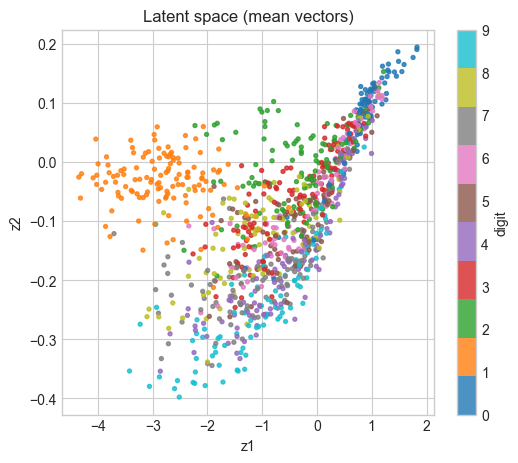

In [7]:
# ------------------------------
# 这段代码做什么：
# 1. 把 2 维潜空间画出来
# 2. 观察不同数字是否形成连续、可解释的区域
# ------------------------------
vae.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for x, y in val_dl:
        x = x.to(device).view(len(x), -1)
        # 这里只看潜空间中心 mu，便于可视化每个样本的位置
        mu, logvar = vae.encode(x)
        all_mu.append(mu.cpu())
        all_labels.append(y)

all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(6, 5))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, s=8, cmap="tab10", alpha=0.8)
plt.colorbar(scatter, label="digit")
plt.title("Latent space (mean vectors)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

### 这段潜空间插值代码在说明什么，它和前面有什么关系

这段代码做的是 **latent interpolation（潜空间插值）**。  
它不是在训练模型，而是在检查：VAE 学到的潜空间是不是连续、平滑、可过渡的。

代码的逻辑可以按 4 步来理解：

1. 从验证集里各找一张图，这里选的是数字 `1` 和数字 `7`
2. 用编码器把它们映射到潜空间，得到两个位置 `mu_a` 和 `mu_b`
3. 在这两个位置之间画一条直线，并在中间取若干个点
4. 把这些中间点送进 decoder，看看会生成什么图像

如果 VAE 学到的潜空间是好的，那么这组图通常会表现成：

- 左边更像 `1`
- 右边更像 `7`
- 中间会出现一些逐渐变化的过渡形态

这说明：

- 潜空间不是乱的
- 相邻位置对应的图像也应该相近
- decoder 不只是“背住训练样本”，而是真的学到了一个连续的生成空间

这段内容和前面三组图是连在一起的：

- **原图 / 重建图**：看 `x -> z -> x_hat` 能不能把原图还原回来
- **潜空间散点图**：看很多样本在潜空间里是怎么分布的
- **潜空间插值**：看两个样本之间的“中间区域”是不是也有合理生成结果

所以前面的逻辑是逐步推进的：

1. 先看单个样本能不能重建
2. 再看很多样本整体分布得是否规整
3. 最后再问：这些点之间的空间，是不是真的有生成意义

这段插值图最重要的结论是：

> 不只是“潜空间分布看起来像一团点”，  
> 更重要的是：**这团点之间的中间区域，也应该对应平滑、有意义的图像变化。**

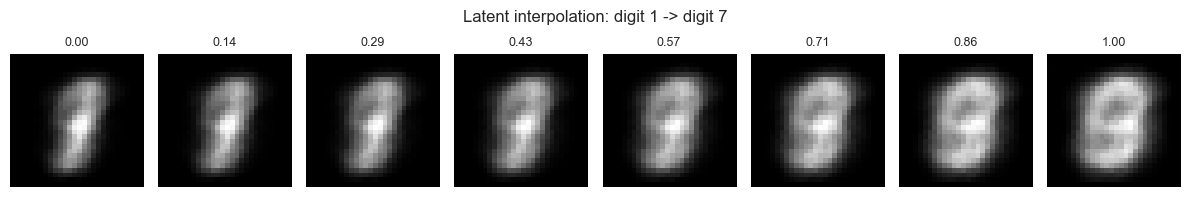

In [8]:
# ------------------------------
# 这段代码做什么：
# 1. 在潜空间里选两张图，做线性插值
# 2. 观察 VAE 是否学到了平滑的生成路径
# ------------------------------
def pick_example(dataset, label):
    for image, y in dataset:
        if int(y) == label:
            return image
    raise ValueError(label)


img_a = pick_example(val_raw, 1).unsqueeze(0).to(device)
img_b = pick_example(val_raw, 7).unsqueeze(0).to(device)

with torch.no_grad():
    # 用两个样本的均值向量作为插值起点和终点
    mu_a, _ = vae.encode(img_a.view(1, -1))
    mu_b, _ = vae.encode(img_b.view(1, -1))

    # 在潜空间里做线性插值，看看 decoder 是否能平滑过渡
    ratios = torch.linspace(0, 1, 8, device=device).unsqueeze(1)
    z_path = (1 - ratios) * mu_a + ratios * mu_b
    decoded = torch.sigmoid(vae.decode(z_path)).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, image, ratio in zip(axes, decoded, torch.linspace(0, 1, 8)):
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"{ratio.item():.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("Latent interpolation: digit 1 -> digit 7")
plt.tight_layout()
plt.show()

### 到这里先收束一下

如果上面的三个结果都看到了，这一部分已经够用了：

- 原图和重建图说明模型确实学到了压缩表示
- 潜空间散点图说明相近样本会聚在相近区域
- 插值结果说明 VAE 的潜空间是连续可走的

但这里也会自然暴露一个问题：

> **VAE 很擅长讲“潜空间”，但生成图像往往偏平滑、偏模糊。**

这就给 diffusion 留出了空间。

# Part 2. 为什么还需要 Diffusion

从生成角度看，VAE 和 diffusion 关注的重点不一样：

- **VAE**：先学一个规则良好的潜空间，再从潜变量解码回图像
- **Diffusion**：把生成问题改写成“不断去噪”的问题

diffusion 的关键想法是：

1. 正向过程很好定义，只要不断往数据里加噪声
2. 反向过程不好手写，但可以训练一个网络去预测“当前噪声长什么样”

<img src="images/lesson5_generative/diffusion_forward_reverse.png" width="980">

### Diffusion 的一句话直觉

- 正向：`x0 -> x1 -> x2 -> ... -> xT`，图像越来越像纯噪声
- 反向：从噪声出发，一步步减去网络预测的噪声，最后回到有结构的样本

和 VAE 对比时，可以先抓住两个差别：

- VAE 一次性把样本映射到潜空间再解码回来
- diffusion 不断迭代，每一步都只做一个很小的去噪动作

### 为什么 diffusion 训练的时候要加噪

先抓住一句话：

> diffusion 训练时加噪，不是为了“增强数据”，而是为了把“直接生成图像”这个难问题，改写成“一步步去噪”这个更容易学的问题。

可以从 4 个角度理解：

1. **生成时本来就是从噪声开始**  
   diffusion 采样时做的是：先从纯噪声 `x_T ~ N(0, I)` 出发，再一步步去噪，最后得到图像 `x_0`。  
   那训练时就必须让模型见过各种“带噪图像”，否则它根本不知道不同噪声强度下应该怎么处理输入。

2. **加噪以后，监督信号就有了**  
   当我们把干净样本 `x_0` 和一份已知噪声 `epsilon` 混合成 `x_t` 时，训练目标就很明确：  
   输入 `(x_t, t)`，让模型预测“当时加进去的噪声 `epsilon`”。  
   因为这份噪声是自己加的，所以标准答案是已知的。

3. **一步生成太难，一步去一点噪更容易**  
   直接学习“从随机噪声一下子生成完整图像”很难。  
   但如果改成“这张有噪图里，多出来的噪声是什么”，这个子任务会简单很多。  
   diffusion 的核心思想，就是把复杂生成任务拆成很多个小的去噪任务。

4. **加噪把真实数据分布连接到了高斯分布**  
   真实图像分布很复杂，但不断加高斯噪声后，样本会逐渐变成接近标准高斯。  
   这样就得到了一条路径：`真实图像分布 -> 加噪 -> 高斯噪声分布`。  
   训练模型学的，正是这条路径的反方向：`高斯噪声 -> 去噪 -> 真实图像`。

也可以用一个更通俗的类比来记：

- 如果只给模型看干净图片，它只知道“好图片长什么样”
- 但它并不知道“坏掉的图片该怎么修”
- diffusion 则是先故意把图片弄脏，再训练模型一步步恢复

所以最关键的一句是：

> 没有加噪，就没有“去噪任务”；  
> 没有去噪任务，模型就学不会从纯噪声一步步走回真实图像。

**论文截图：Denoising Diffusion Probabilistic Models, Ho et al., 2020**

<img src="images/lesson5_generative/ddpm_paper_fig.png" width="860">

这张图来自原论文的 Figure 2。它把 diffusion 最核心的一点画得很直接：

- 训练时看的是整条随机变量链
- 采样时实际上是在做从 `x_T` 一步步回到 `x_0` 的马尔可夫反推

论文链接：<https://arxiv.org/abs/2006.11239>

## 先用一张数字图像观察“加噪过程”

在真正训练 diffuser 之前，先把正向过程看清楚。  
这里使用 `DDPMScheduler` 来做前向加噪，不需要先训练网络。

可以先想一个问题：

> 如果某个时刻的图像已经非常像噪声了，模型在训练时最直接、最稳定的学习目标应该是什么？

后面会看到，答案通常是：**预测加进去的噪声 `epsilon`**。

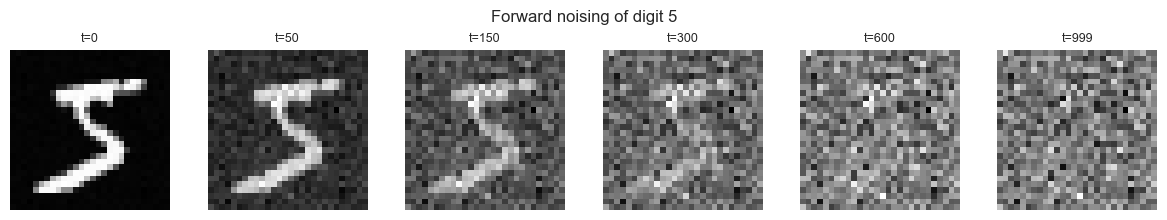

In [9]:
# ------------------------------
# 这段代码做什么：
# 1. 使用 DDPMScheduler 对单张数字图像逐步加噪
# 2. 直观看到 x_t 随时间步变得越来越乱
# ------------------------------
scheduler_img = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")
image0, label0 = train_raw[0]
x0 = image0.unsqueeze(0)

timesteps_to_show = [0, 50, 150, 300, 600, 999]
# 固定同一份噪声，便于纯粹观察 t 改变时的加噪强度变化
noise = torch.randn_like(x0)

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(12, 2.2))
for ax, t in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t], dtype=torch.long)
    # scheduler 负责把干净样本 x0 和噪声 epsilon 混合成 x_t
    noisy = scheduler_img.add_noise(x0, noise, t_tensor)
    ax.imshow(noisy.squeeze(0).squeeze(0).cpu(), cmap="gray")
    ax.set_title(f"t={t}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Forward noising of digit {label0}")
plt.tight_layout()
plt.show()

### 这一步要讲透什么

1. `t` 越大，保留的原图信息越少
2. 同一张 `x0` 配合同一份噪声，`t` 不同会得到不同强度的 `x_t`
3. 训练时并不是让网络直接从纯噪声一步变成图像，而是学会在任意 `t` 上预测噪声

这也是 diffusion 比较稳的一点：每个训练样本都能通过不同的时间步生成很多训练对 `(x_t, t, epsilon)`。

# Part 3. 一个从零可跑的最小 Diffuser

直接在图像上从零训练 DDPM，CPU 上不太友好。  
所以这里先做一个**二维点云版本**，把核心机制讲透：

- 数据：`two moons`
- 正向：给点不断加噪
- 反向：训练一个 MLP 预测噪声

这个例子虽然不是图像，但训练目标、时间步条件、反向采样逻辑和图像 diffusion 是同一套。

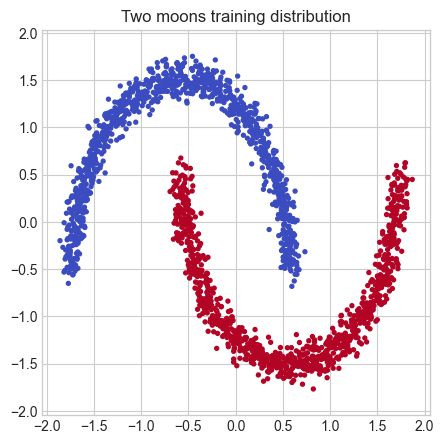

In [10]:
# ------------------------------
# 这段代码做什么：
# 1. 生成 two moons 数据
# 2. 作为一个最小“数据分布”，用来观察 diffusion 的采样过程
# ------------------------------
moon_x, moon_y = make_moons(n_samples=2048, noise=0.05, random_state=SEED)
moon_x = torch.tensor(moon_x, dtype=torch.float32)
# 先做标准化，方便后面训练稳定一些
moon_x = (moon_x - moon_x.mean(0, keepdim=True)) / moon_x.std(0, keepdim=True)

plt.figure(figsize=(5, 5))
plt.scatter(moon_x[:, 0], moon_x[:, 1], c=moon_y, s=8, cmap="coolwarm")
plt.title("Two moons training distribution")
plt.axis("equal")
plt.show()

In [11]:
# ------------------------------
# 这段代码做什么：
# 1. 定义时间步 embedding
# 2. 定义一个最小噪声预测网络 epsilon_theta(x_t, t)
# ------------------------------
moon_scheduler = DDPMScheduler(
    num_train_timesteps=100,
    beta_schedule="squaredcos_cap_v2",
    clip_sample=False,
)


def timestep_embedding(timesteps, dim=32):
    half = dim // 2
    # 用正弦位置编码把离散时间步 t 变成连续向量
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, dtype=torch.float32, device=timesteps.device) / (half - 1)
    )
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros(len(timesteps), 1, device=timesteps.device)], dim=1)
    return emb


class ToyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        # 输入是 [x_t, time_embedding]，输出是预测噪声 epsilon_hat
        self.net = nn.Sequential(
            nn.Linear(2 + 32, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 2),
        )

    def forward(self, x_t, t):
        emb = timestep_embedding(t, dim=32)
        return self.net(torch.cat([x_t, emb], dim=1))


toy_model = ToyDenoiser().to(device)
toy_opt = torch.optim.Adam(toy_model.parameters(), lr=1e-3)
print(toy_model)

ToyDenoiser(
  (net): Sequential(
    (0): Linear(in_features=34, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [12]:
# ------------------------------
# 这段代码做什么：
# 1. 训练 toy diffuser 去预测噪声
# 2. 观察 loss 是否下降到一个稳定范围
# ------------------------------
toy_losses = []
batch_size = 256

for step in range(800):
    # 1) 随机采一个 batch 的干净样本 x0
    idx = torch.randint(0, len(moon_x), (batch_size,))
    x0 = moon_x[idx].to(device)
    # 2) 随机采一个时间步 t，让模型看到不同噪声强度
    t = torch.randint(0, moon_scheduler.config.num_train_timesteps, (batch_size,), device=device).long()
    # 3) 构造真实噪声 epsilon，并得到 x_t
    noise = torch.randn_like(x0)
    x_t = moon_scheduler.add_noise(x0, noise, t)

    # 4) 让模型预测“加进去的是哪一份噪声”
    pred_noise = toy_model(x_t, t)
    loss = F.mse_loss(pred_noise, noise)

    toy_opt.zero_grad()
    loss.backward()
    toy_opt.step()

    toy_losses.append(float(loss.item()))

print("final loss =", round(toy_losses[-1], 4))

final loss = 0.5135


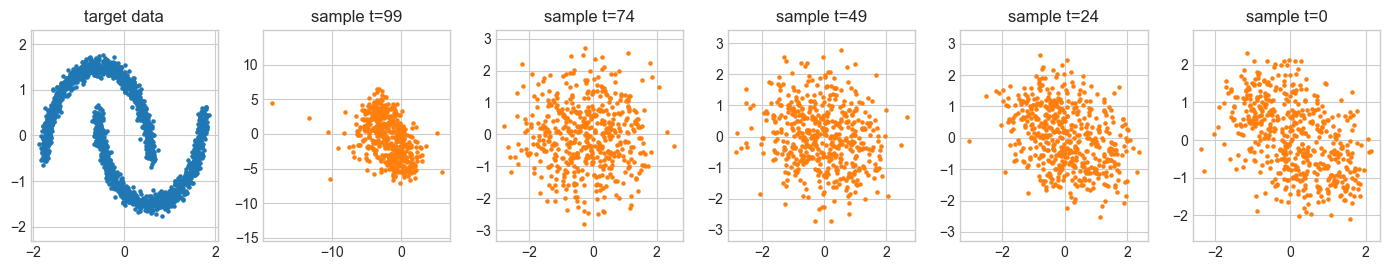

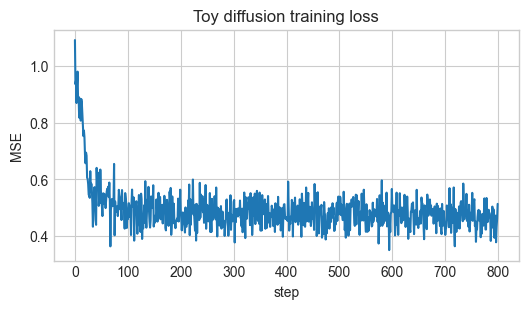

In [13]:
# ------------------------------
# 这段代码做什么：
# 1. 从纯噪声开始反向采样
# 2. 记录若干中间步骤，看看点云如何逐渐“长回去”
# ------------------------------
toy_model.eval()
moon_scheduler.set_timesteps(100)
# 采样起点是纯高斯噪声，不再是真实数据点
x_t = torch.randn(512, 2, device=device)
snapshots = []
keep_steps = {99, 74, 49, 24, 0}

for t in moon_scheduler.timesteps:
    t_batch = torch.full((len(x_t),), int(t.item()), device=device, dtype=torch.long)
    with torch.no_grad():
        pred_noise = toy_model(x_t, t_batch)
    # scheduler.step 会根据预测噪声把 x_t 更新到前一个时间步
    x_t = moon_scheduler.step(pred_noise, t, x_t).prev_sample
    if int(t.item()) in keep_steps:
        snapshots.append((int(t.item()), x_t.detach().cpu().clone()))

fig, axes = plt.subplots(1, len(snapshots) + 1, figsize=(14, 2.8))
axes[0].scatter(moon_x[:, 0], moon_x[:, 1], s=5, c="tab:blue")
axes[0].set_title("target data")
axes[0].axis("equal")

for ax, (t_show, points) in zip(axes[1:], snapshots):
    ax.scatter(points[:, 0], points[:, 1], s=5, c="tab:orange")
    ax.set_title(f"sample t={t_show}")
    ax.axis("equal")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(toy_losses)
plt.title("Toy diffusion training loss")
plt.xlabel("step")
plt.ylabel("MSE")
plt.show()

### 这里和图像 diffusion 的联系是什么

这个例子虽然是二维点，不是图像，但有三个关键结构已经完全对上了：

1. **随机时间步 `t`**
2. **对 `x_t` 预测噪声 `epsilon`**
3. **从随机噪声出发，用 scheduler 反向走回数据分布**

所以下一步只需要把“二维点的 MLP”替换成“图像上的 U-Net”，就已经进入真正的图像 diffusion 了。

# Part 4. 图像 Diffusion 里的 U-Net 和条件信息

在图像上，噪声预测网络通常不会再用简单 MLP，而是用 **U-Net**。原因很直接：

- 图像有空间结构
- 既需要局部细节，也需要全局上下文
- 反向去噪需要多尺度信息和跳跃连接

所以这一步的重点不是把 U-Net 每个 block 背下来，而是先抓住它在 diffusion 里的角色：

> **输入 `x_t` 和 `t`，输出对噪声 `epsilon` 的预测。**

In [14]:
# ------------------------------
# 这段代码做什么：
# 1. 构造一个和原始示例思路一致、但更轻量的 UNet2DModel
# 2. 观察图像 diffusion 中的输入输出 shape
# ------------------------------
image_unet = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=1,
    block_out_channels=(32, 64, 64),
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
).to(device)

total_params = sum(p.numel() for p in image_unet.parameters())
print("UNet parameters =", total_params)

x_batch, y_batch = next(iter(train_dl))
x_batch = x_batch[:4].to(device)
# 图像 diffusion 里，每张图也要配一个时间步条件
timesteps = torch.randint(0, 1000, (len(x_batch),), device=device).long()

with torch.no_grad():
    pred_noise = image_unet(x_batch, timesteps).sample

print("input shape :", tuple(x_batch.shape))
print("t shape     :", tuple(timesteps.shape))
print("output shape:", tuple(pred_noise.shape))
print("first down block:", image_unet.down_blocks[0].__class__.__name__)
print("mid block      :", image_unet.mid_block.__class__.__name__)
print("first up block :", image_unet.up_blocks[0].__class__.__name__)

UNet parameters = 1163105
input shape : (4, 1, 28, 28)
t shape     : (4,)
output shape: (4, 1, 28, 28)
first down block: DownBlock2D
mid block      : UNetMidBlock2D
first up block : AttnUpBlock2D


In [15]:
# ------------------------------
# 这段代码做什么：
# 1. 用一个最小例子演示“条件信息如何进入扩散模型”
# 2. 对应条件 diffusion 的原始示例思路
# ------------------------------
label_embedding = nn.Embedding(num_embeddings=10, embedding_dim=4).to(device)
labels = torch.tensor([0, 1, 2, 3], device=device)
# 先把类别索引变成向量，再扩展成 H x W 的特征图
label_feat = label_embedding(labels)[:, :, None, None]
label_feat = label_feat.expand(-1, -1, 28, 28)
# 最简单的条件注入方式之一：直接在 channel 维拼接
conditioned_input = torch.cat([x_batch, label_feat], dim=1)

print("original image channels     :", x_batch.shape[1])
print("label embedding channels    :", label_feat.shape[1])
print("conditioned input channels  :", conditioned_input.shape[1])

original image channels     : 1
label embedding channels    : 4
conditioned input channels  : 5


### 这一小节要强调什么

1. `U-Net` 负责做**空间去噪**
2. `timestep embedding` 负责告诉网络“当前去噪进度”
3. 额外条件可以通过多种方式注入：拼接、cross-attention、adapter、ControlNet

所以从 `Diffusion_Pytorch.ipynb` 到 `Conditional_Diffuser_training.ipynb`，本质变化只有一个：

> **不再只给模型噪声图，还给它附加条件。**

# Part 5. Stable Diffusion：为什么要在 latent space 里做 diffusion

直接在像素空间做 diffusion 当然可以，但代价很大：

- 图像维度高
- 推理步骤多
- 大分辨率生成成本高

Stable Diffusion 的核心改动是：

1. 先用一个 VAE 把图像压到 latent space
2. 再在 latent 上做 diffusion
3. 最后再用 VAE decoder 把 latent 解码回像素

<img src="images/lesson5_generative/latent_diffusion_pipeline.png" width="1020">

### 这里和前面 VAE / Diffusion 的联系

- **VAE 部分** 提供了“图像 <-> latent”这座桥
- **Diffusion 部分** 提供了“在 latent 里逐步去噪生成”的主干
- **Text encoder** 把 prompt 变成条件信号
- **Scheduler** 负责定义采样时间步和更新规则

可以把 Stable Diffusion 理解成：

> **VAE + conditional latent diffusion + scheduler + classifier-free guidance**

**论文截图：High-Resolution Image Synthesis with Latent Diffusion Models, Rombach et al., 2022**

<img src="images/lesson5_generative/ldm_paper_fig.png" width="860">

这张图来自原论文的 Figure 3。讲 Stable Diffusion 时，它特别适合用来回答两个问题：

- 为什么还需要一个 VAE？
- 文本条件是怎样进入 latent diffusion 主干的？

论文链接：<https://arxiv.org/abs/2112.10752>

In [16]:
# ------------------------------
# 这段代码做什么：
# 1. 给出一个 Stable Diffusion 的最小可选演示入口
# 2. 默认不运行大模型，避免 CPU 课堂环境被卡住
# ------------------------------
if RUN_HEAVY_MODELS:
    from diffusers import DiffusionPipeline

    tiny_model_id = "hf-internal-testing/tiny-stable-diffusion-pipe"
    sd_pipe = DiffusionPipeline.from_pretrained(tiny_model_id)
    sd_pipe = sd_pipe.to(device)

    out = sd_pipe(
        prompt="a toy robot reading a book",
        num_inference_steps=10,
        guidance_scale=5.0,
    )
    display(out.images[0])
else:
    print("跳过 Stable Diffusion 推理。")
    print("如需运行，可把 RUN_HEAVY_MODELS 改成 True，并在更强的机器上执行这一格。")

跳过 Stable Diffusion 推理。
如需运行，可把 RUN_HEAVY_MODELS 改成 True，并在更强的机器上执行这一格。


### 提问环节

这里可以停一下，追问两个问题：

- 既然前面已经讲过 VAE，为什么 Stable Diffusion 还要再保留一个 VAE？
- 如果不在 latent space 里做 diffusion，而是在原图像上做，会多出哪些计算代价？

把这两个问题讲顺，Stable Diffusion 的工程动机就比较清楚了。

# Part 6. ControlNet：如何把“结构约束”加进来

text prompt 能控制语义，但通常不够控制几何结构。  
ControlNet 的目标，就是在不推翻 Stable Diffusion 主干的前提下，再给一个额外的结构条件，例如：

- 边缘图
- 深度图
- 姿态骨架
- 分割图

<img src="images/lesson5_generative/controlnet_concept.png" width="980">

### 这部分和 ControlNet 原始示例的联系

`ControlNet-Inference.ipynb` 里的核心流程其实很简单：

1. 先把原始图像变成控制图，例如 `canny edge`
2. 把控制图和 prompt 一起送进 `StableDiffusionControlNetPipeline`
3. 由 ControlNet 提供额外特征，约束输出结构

**论文截图：Adding Conditional Control to Text-to-Image Diffusion Models, Zhang et al., 2023**

<img src="images/lesson5_generative/controlnet_paper_fig.png" width="760">

这张图来自原论文的 Figure 3。课堂上最值得强调的是：

- 左边是原本 Stable Diffusion 的 U-Net 主干
- 右边多出来的是可训练副本和 zero convolution
- 这样做的目的，是在不破坏原主干能力的前提下，把结构条件注入进去

论文链接：<https://arxiv.org/abs/2302.05543>

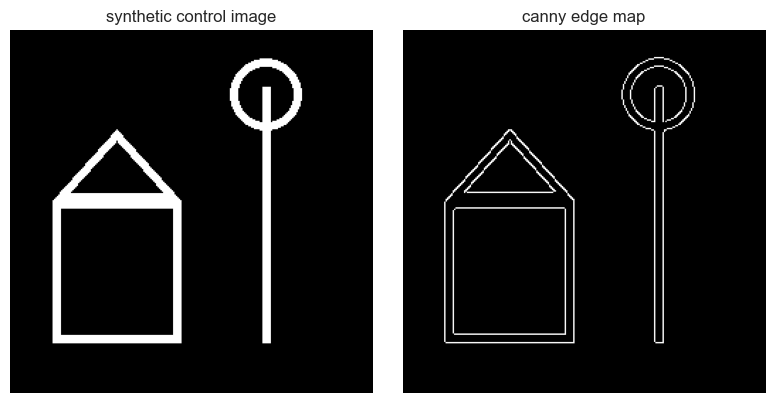

In [17]:
# ------------------------------
# 这段代码做什么：
# 1. 构造一张简单的“控制图”
# 2. 用 Canny 提取边缘，模拟 ControlNet 的输入
# ------------------------------
control_canvas = Image.new("L", (256, 256), color=0)
draw = ImageDraw.Draw(control_canvas)
# 手工画一个非常简单的房子 + 树的轮廓，模拟“结构条件”
draw.rectangle((30, 120, 120, 220), outline=255, width=6)
draw.polygon([(120, 120), (75, 70), (30, 120)], outline=255, width=6)
draw.line((180, 40, 180, 220), fill=255, width=6)
draw.ellipse((155, 20, 205, 70), outline=255, width=6)

# 用 Canny 边缘检测把结构轮廓提取出来
edge_map = cv2.Canny(np.array(control_canvas), threshold1=60, threshold2=150)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(control_canvas, cmap="gray")
axes[0].set_title("synthetic control image")
axes[0].axis("off")

axes[1].imshow(edge_map, cmap="gray")
axes[1].set_title("canny edge map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [18]:
# ------------------------------
# 这段代码做什么：
# 1. 给出一个 ControlNet 推理模板
# 2. 默认不运行，避免在 CPU 环境里下载和推理大模型
# ------------------------------
if RUN_HEAVY_MODELS and torch.cuda.is_available():
    from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, DPMSolverMultistepScheduler

    controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny")
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
    ).to(device)
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    control_rgb = Image.fromarray(np.stack([edge_map] * 3, axis=-1))
    out = pipe(
        prompt="a clean architectural sketch transformed into a realistic house",
        image=control_rgb,
        num_inference_steps=20,
        controlnet_conditioning_scale=0.8,
    )
    display(out.images[0])
else:
    print("跳过 ControlNet 推理。")
    print("上面这格的重点是把 ControlNet 的推理接口和控制图流程理顺。")

跳过 ControlNet 推理。
上面这格的重点是把 ControlNet 的推理接口和控制图流程理顺。


# 小结

这一讲可以最后收成六句话：

1. Autoencoder 擅长压缩和重建，但普通 AE 的潜空间不一定适合生成。
2. VAE 用 `mu`、`logvar` 和 KL 正则，把潜空间变成了可采样的连续分布。
3. diffusion 把生成问题改写成“学习如何去掉噪声”。
4. 图像 diffusion 的核心网络通常是 U-Net，核心训练目标通常是预测噪声。
5. Stable Diffusion 把 diffusion 放到 latent space 里做，显著降低了生成成本。
6. ControlNet 在文本条件之外，再加上结构条件，让生成结果更可控。

## 课后可以继续追问的三个问题

- 如果把 VAE 的 `beta` 调大，重建质量和潜空间规则性会怎么变化？
- diffusion 为什么常用“预测噪声”而不是直接预测干净图像？
- ControlNet 和简单的 prompt engineering，本质上分别在控制什么？